## 📦 Imports et configuration

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# === Paths ===
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) if "__file__" in locals() else os.path.abspath("..")
DATA_PATH = os.path.join(BASE_DIR, "data", "raw", "earthquake_data_tsunami.csv")



## 📥 Chargement des données

In [18]:
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(f"Dataset non trouvé : {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print('Dimensions :', df.shape)
print('Colonnes :', df.columns.tolist())
df.head()

Dimensions : (782, 13)
Colonnes : ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [19]:
df = df.drop_duplicates()
df = df.fillna(df.mean())

print("✅ Data cleaned — no missing values remain.")


✅ Data cleaned — no missing values remain.


##  Nettoyage et préparation

In [20]:
TARGET = 'tsunami'
if TARGET not in df.columns:
    raise ValueError(f"Colonne cible '{TARGET}' absente.")

df[TARGET] = df[TARGET].astype(int)

for col in ['Year', 'Month']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

print("Valeurs manquantes :")
print(df.isnull().sum())

Valeurs manquantes :
magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64


Text(0.5, 1.0, 'Répartition des classes tsunami')

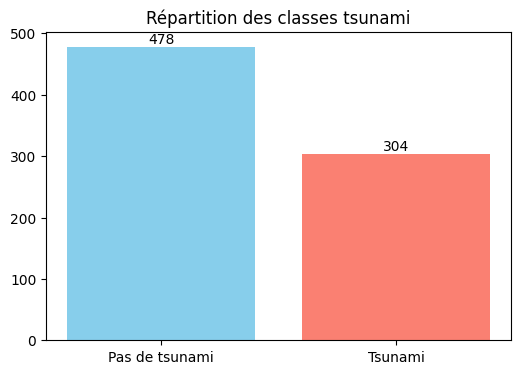

In [21]:
fig = plt.figure(figsize=(6,4))
counts = df[TARGET].value_counts().sort_index()
bars = plt.bar(['Pas de tsunami', 'Tsunami'], counts.values, color=['skyblue', 'salmon'])
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, str(h), ha='center', va='bottom')
plt.title("Répartition des classes tsunami")


Text(0.5, 0, 'Magnitude')

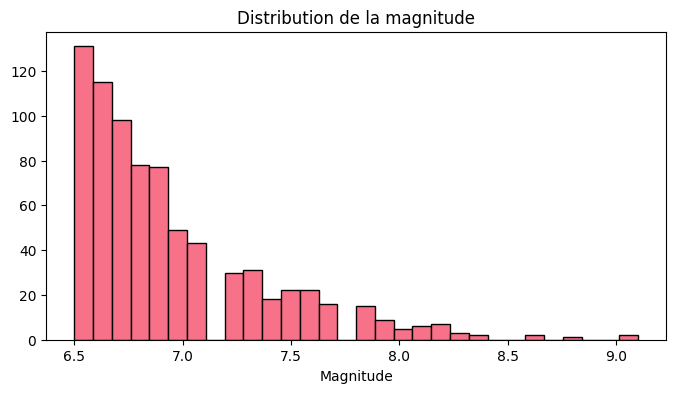

In [22]:
fig = plt.figure(figsize=(8,4))
plt.hist(df['magnitude'], bins=30, edgecolor='k')
plt.title('Distribution de la magnitude')
plt.xlabel('Magnitude')


Text(0.5, 1.0, 'Magnitude - Tsunami')

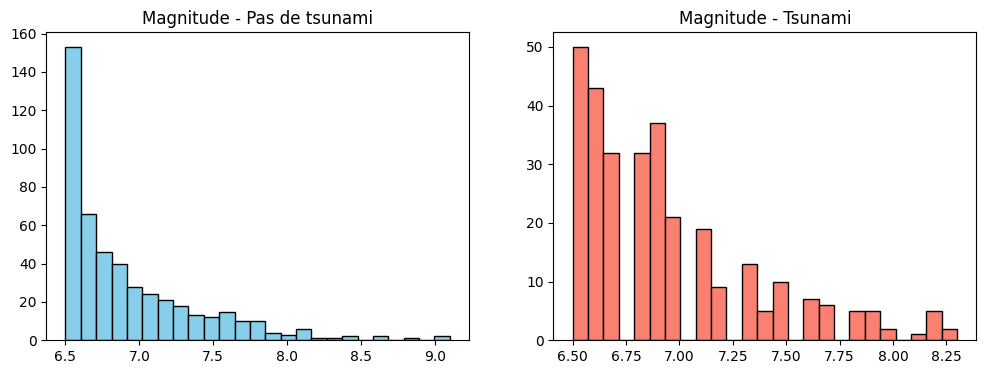

In [23]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(df.loc[df[TARGET]==0,'magnitude'], bins=25, color='skyblue', edgecolor='k')
ax[0].set_title('Magnitude - Pas de tsunami')
ax[1].hist(df.loc[df[TARGET]==1,'magnitude'], bins=25, color='salmon', edgecolor='k')
ax[1].set_title('Magnitude - Tsunami')


Text(0.5, 1.0, 'Profondeur par classe')

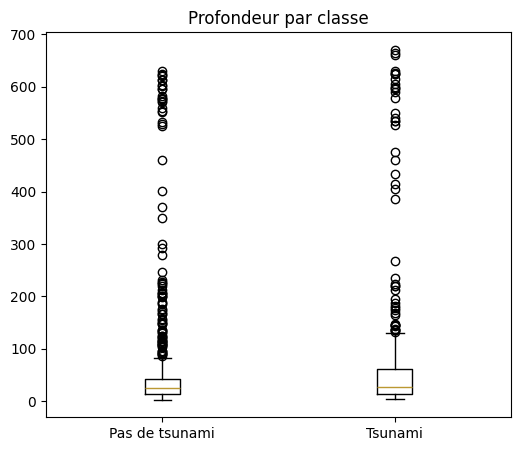

In [24]:
fig = plt.figure(figsize=(6,5))
plt.boxplot([df.loc[df[TARGET]==0,'depth'].dropna(),
             df.loc[df[TARGET]==1,'depth'].dropna()],
            labels=['Pas de tsunami', 'Tsunami'])
plt.title('Profondeur par classe')


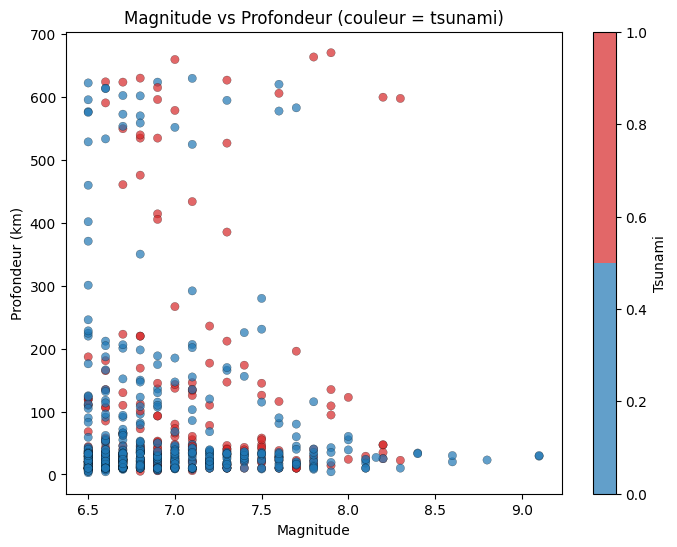

In [25]:
fig = plt.figure(figsize=(8,6))
colors = ListedColormap(['tab:blue','tab:red'])
plt.scatter(df['magnitude'], df['depth'], c=df[TARGET], cmap=colors, alpha=0.7, edgecolor='k', linewidth=0.2)
plt.xlabel('Magnitude')
plt.ylabel('Profondeur (km)')
plt.title('Magnitude vs Profondeur (couleur = tsunami)')
plt.colorbar(label='Tsunami')


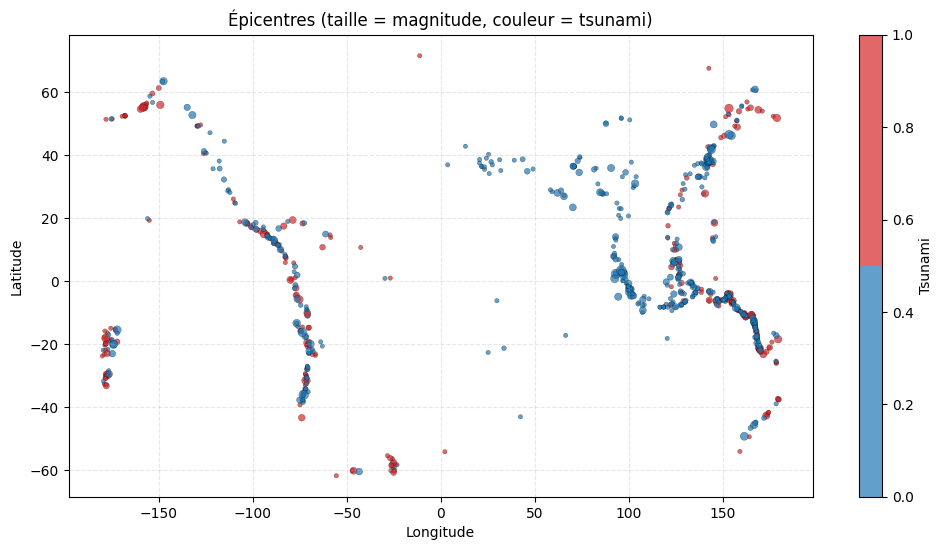

In [26]:
fig = plt.figure(figsize=(12,6))
sizes = np.clip((df['magnitude']-6.4)*20, 10, 300)
plt.scatter(df['longitude'], df['latitude'], c=df[TARGET], s=sizes, alpha=0.7, cmap=colors, edgecolor='k', linewidth=0.2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Épicentres (taille = magnitude, couleur = tsunami)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(label='Tsunami')


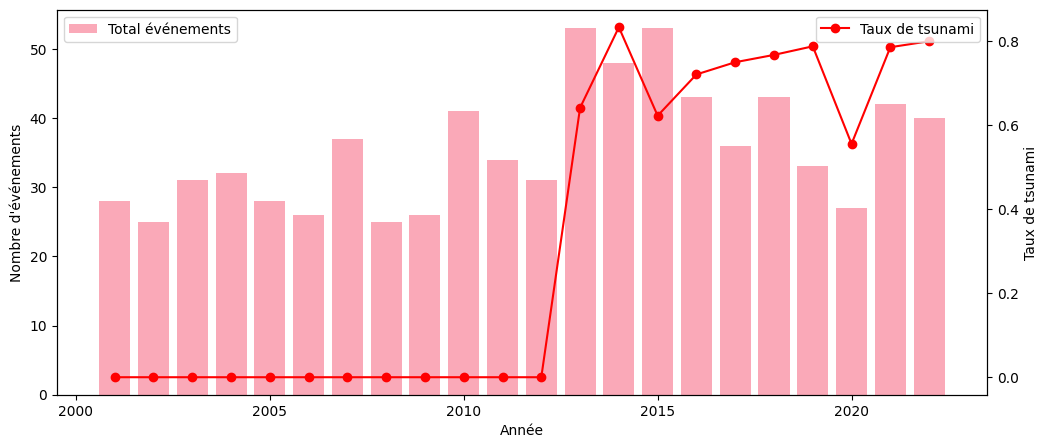

In [27]:
if 'Year' in df.columns:
    yearly = df.groupby('Year')[TARGET].agg(['count','sum'])
    yearly['tsunami_rate'] = yearly['sum'] / yearly['count']
    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.bar(yearly.index, yearly['count'], alpha=0.6, label='Total événements')
    ax1.set_ylabel('Nombre d\'événements')
    ax2 = ax1.twinx()
    ax2.plot(yearly.index, yearly['tsunami_rate'], color='red', marker='o', label='Taux de tsunami')
    ax2.set_ylabel('Taux de tsunami')
    ax1.set_xlabel('Année')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
 

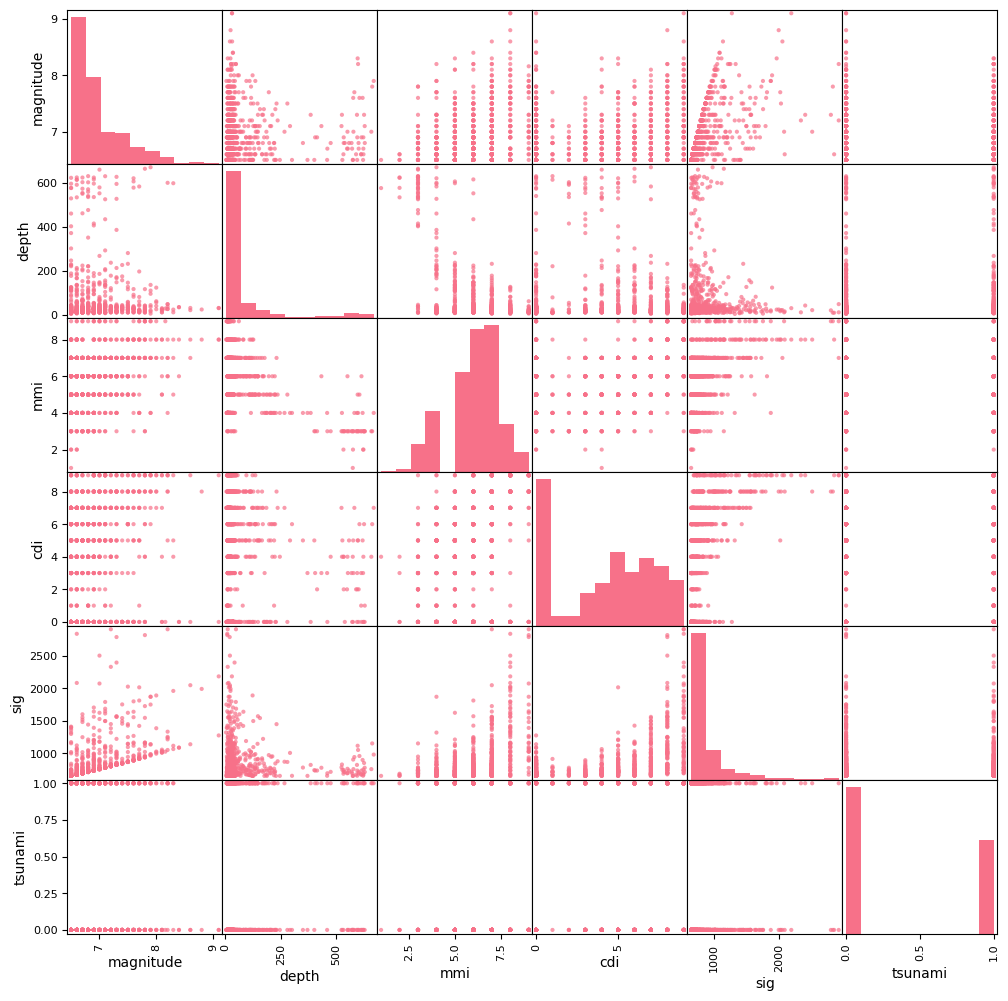

In [28]:
selected = ['magnitude','depth','mmi','cdi','sig', TARGET]
available = [c for c in selected if c in df.columns]
if len(available) >= 3:
    fig = scatter_matrix(df[available], alpha=0.7, figsize=(12,12), diagonal='hist')
  

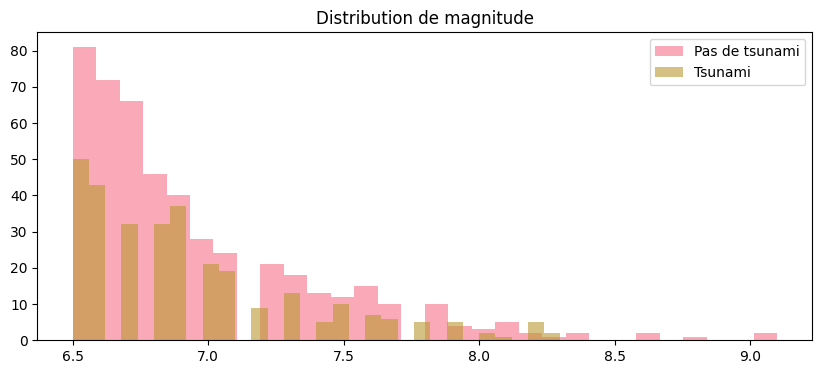

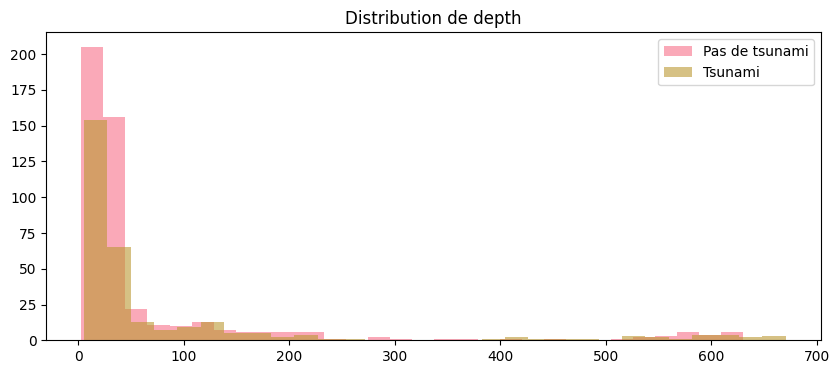

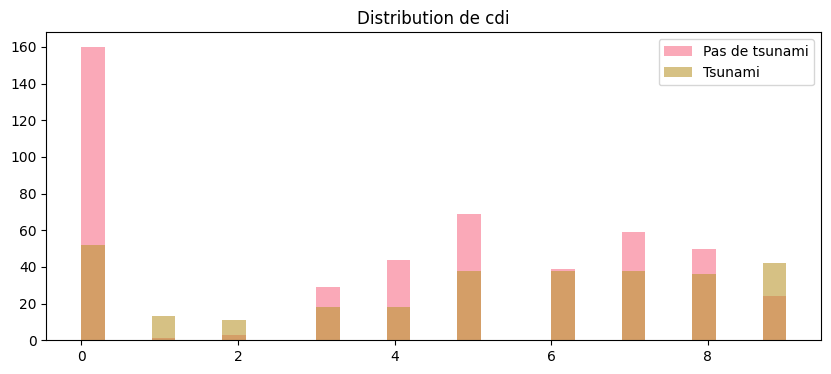

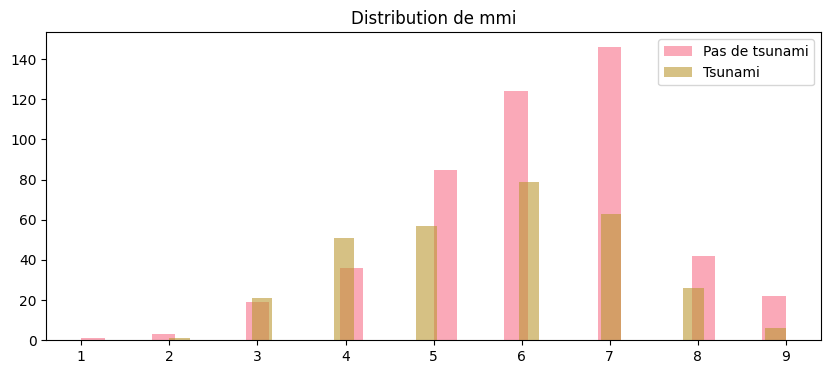

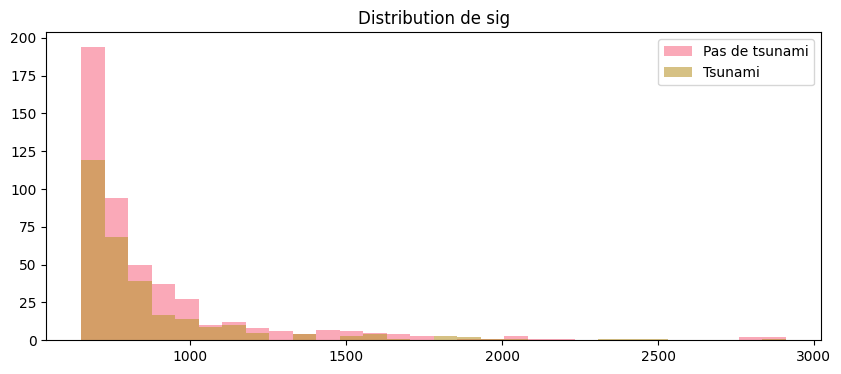

In [29]:
key_feats = ['magnitude','depth','cdi','mmi','sig']
feats = [f for f in key_feats if f in df.columns]
for feat in feats:
    fig = plt.figure(figsize=(10,4))
    plt.hist(df.loc[df[TARGET]==0, feat], bins=30, alpha=0.6, label='Pas de tsunami')
    plt.hist(df.loc[df[TARGET]==1, feat], bins=30, alpha=0.6, label='Tsunami')
    plt.title(f'Distribution de {feat}')
    plt.legend()
   

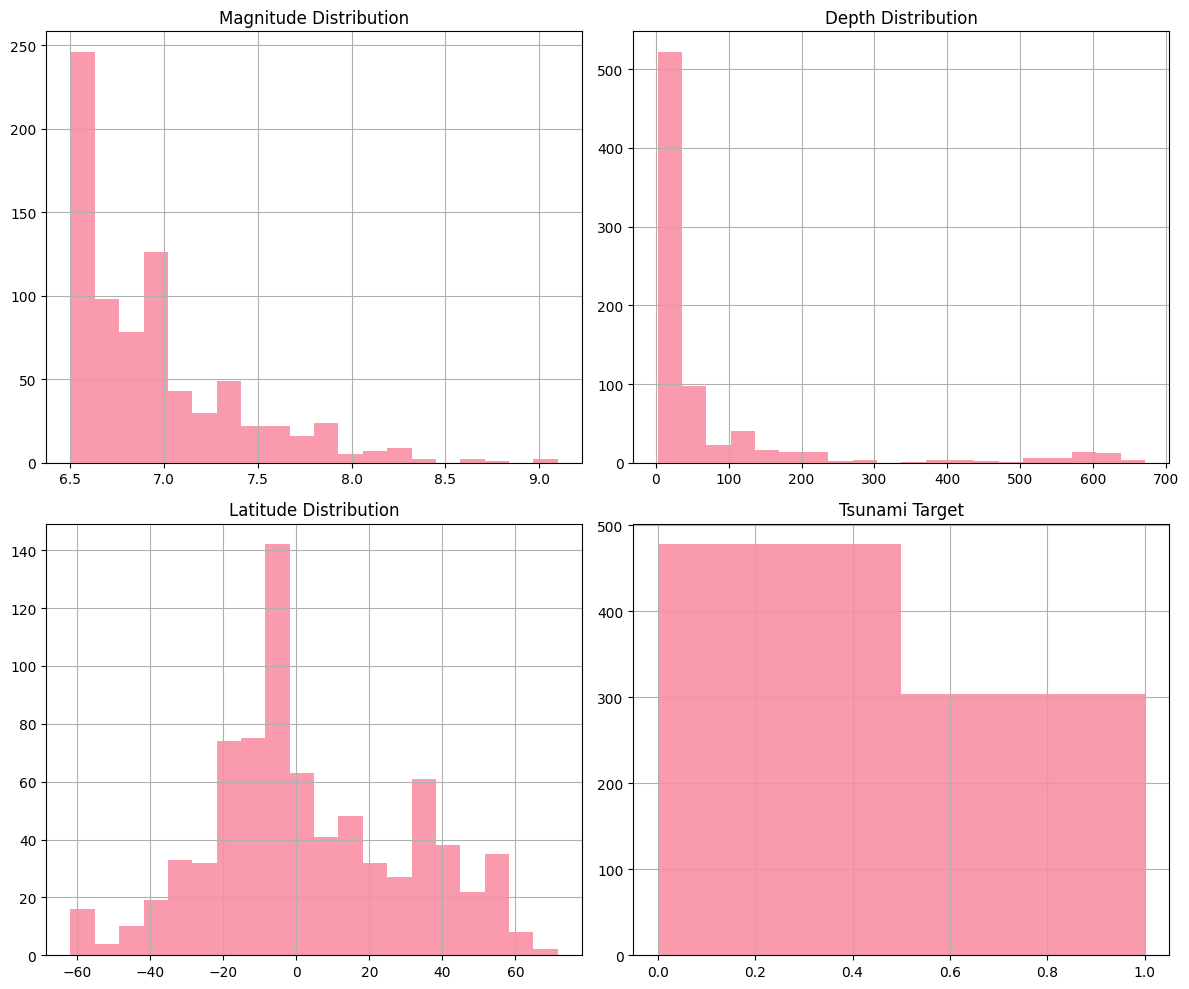

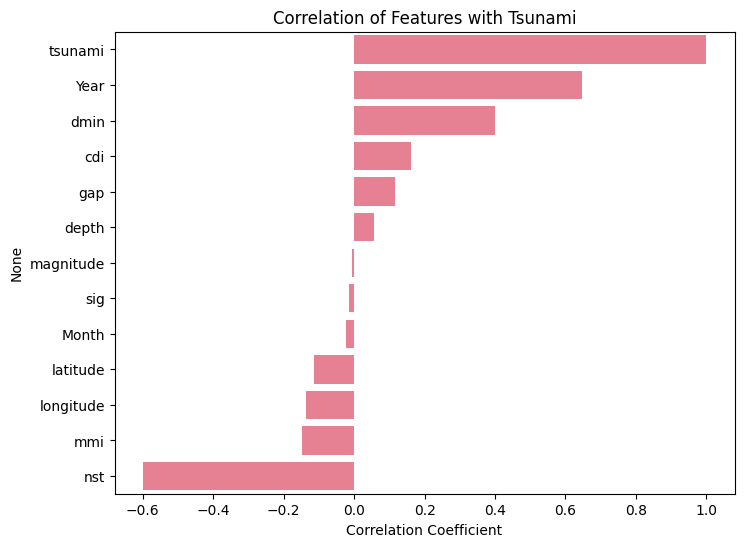

In [30]:
import seaborn as sns
# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Distribution histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df['magnitude'].hist(ax=axes[0,0], bins=20, alpha=0.7); axes[0,0].set_title('Magnitude Distribution')
df['depth'].hist(ax=axes[0,1], bins=20, alpha=0.7); axes[0,1].set_title('Depth Distribution')
df['latitude'].hist(ax=axes[1,0], bins=20, alpha=0.7); axes[1,0].set_title('Latitude Distribution')
df['tsunami'].hist(ax=axes[1,1], bins=2, alpha=0.7); axes[1,1].set_title('Tsunami Target')
plt.tight_layout()
plt.show()

# Correlation with target
corr = df.corr()['tsunami'].sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index)
plt.title('Correlation of Features with Tsunami')
plt.xlabel('Correlation Coefficient')
plt.show()


In [31]:
if 'depth' in df.columns:
    df['is_shallow'] = (df['depth'] <= 70).astype(int)

features = ['magnitude','depth','cdi','mmi','sig','nst','dmin','gap','is_shallow']
features = [f for f in features if f in df.columns]
print('Features sélectionnées :', features)

Features sélectionnées : ['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'is_shallow']


In [32]:
model_df = df[features + [TARGET]].dropna()
X = model_df[features].copy()
y = model_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# --- 1️⃣ Grid Search Parameters for XGBoost ---
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=(y.value_counts()[0] / y.value_counts()[1])  # handle imbalance
)

# --- 2️⃣ Grid Search ---
grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='roc_auc',
    verbose=2
)

grid.fit(X_train_scaled, y_train)

print("✅ Best Parameters:", grid.best_params_)
print("✅ Best Cross-Validation ROC AUC:", grid.best_score_)

# --- 3️⃣ Train Best XGBoost Model ---
best_xgb = grid.best_estimator_
best_xgb.fit(X_train_scaled, y_train)

# --- 4️⃣ Evaluate on Test Data ---
y_pred = best_xgb.predict(X_test_scaled)
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred))

print("✅ Test Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("✅ ROC AUC Score :", round(roc_auc_score(y_test, y_proba), 4))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
✅ Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
✅ Best Cross-Validation ROC AUC: 0.88606255899489

📊 Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      0.90      0.91        96
           1       0.84      0.87      0.85        61

    accuracy                           0.89       157
   macro avg       0.88      0.88      0.88       157
weighted avg       0.89      0.89      0.89       157

✅ Test Accuracy : 0.8854
✅ ROC AUC Score : 0.9308


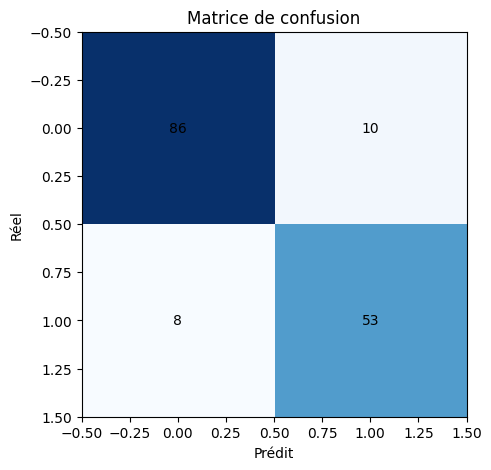

In [34]:
cm = confusion_matrix(y_test, y_pred)
fig = plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center')


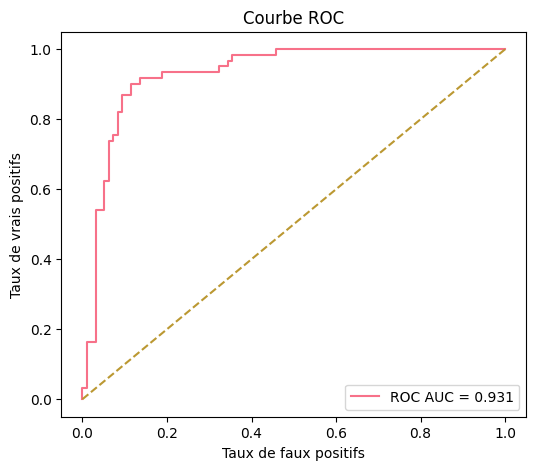

In [35]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig = plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC')
plt.legend()



📊 Rapport de classification :
              precision    recall  f1-score   support

           0       0.91      0.90      0.91        96
           1       0.84      0.87      0.85        61

    accuracy                           0.89       157
   macro avg       0.88      0.88      0.88       157
weighted avg       0.89      0.89      0.89       157


✅ Metrics Summary:
Train Accuracy : 0.9504
Test Accuracy  : 0.8854
ROC AUC Score  : 0.9308
RMSE           : 0.3102
MAE            : 0.1932
R² Score       : 0.5950


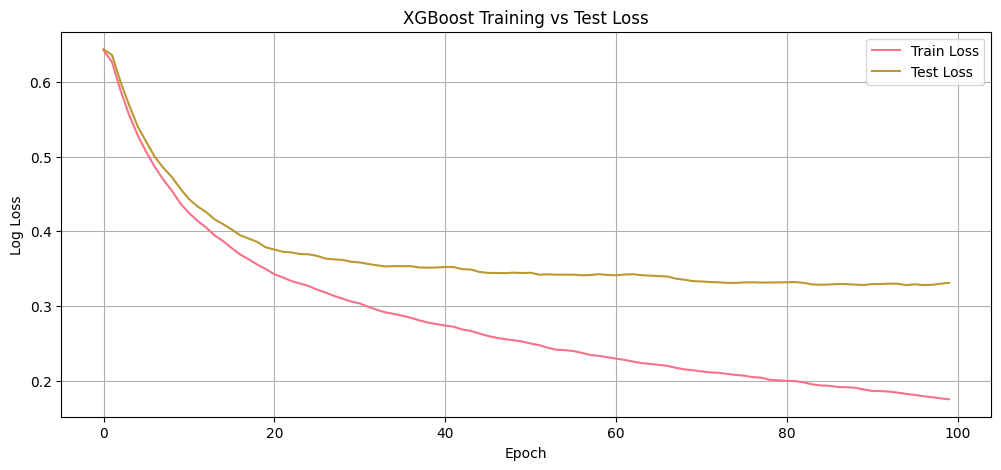

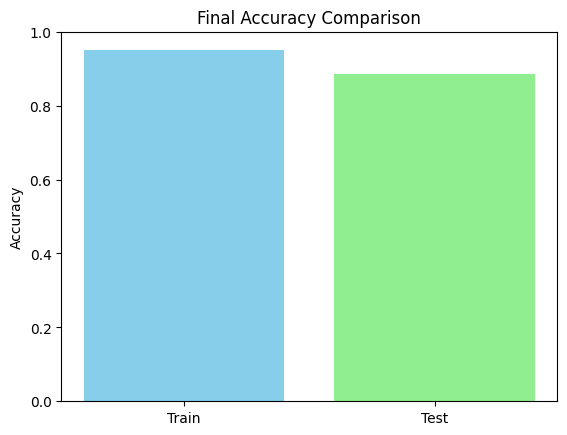

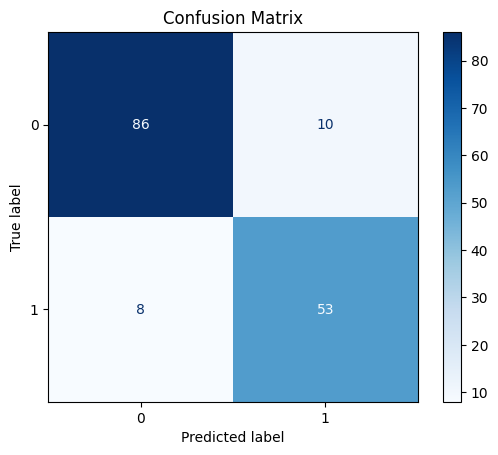

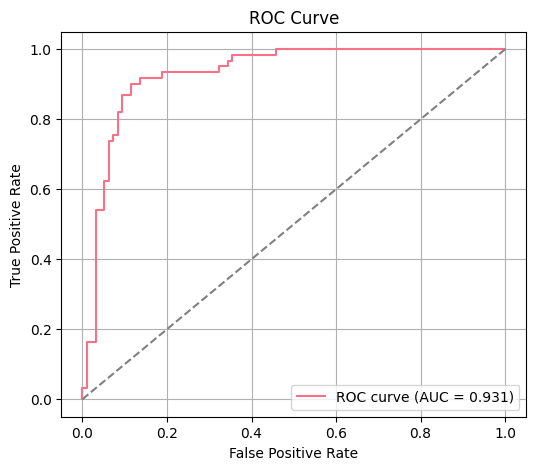

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

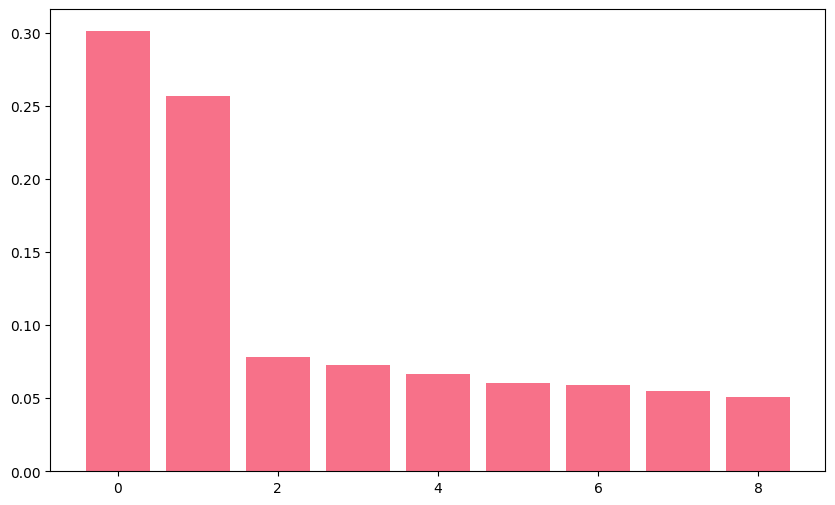

In [36]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_curve, auc
)

# --- 3️⃣ Train Best Model ---
best_xgb = grid.best_estimator_

best_xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

# Retrieve training history
evals_result = best_xgb.evals_result()

# --- 4️⃣ Predictions ---
y_pred_train = best_xgb.predict(X_train_scaled)
y_pred_test = best_xgb.predict(X_test_scaled)
y_proba_test = best_xgb.predict_proba(X_test_scaled)[:, 1]

# --- 5️⃣ Metrics ---
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

# Regression-style metrics (use probabilities)
rmse = np.sqrt(mean_squared_error(y_test, y_proba_test))
mae = mean_absolute_error(y_test, y_proba_test)
r2 = r2_score(y_test, y_proba_test)

print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred_test))

print("\n✅ Metrics Summary:")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"ROC AUC Score  : {roc_auc:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"R² Score       : {r2:.4f}")

# --- 6️⃣ Plot Log Loss Curve ---
epochs = range(len(evals_result['validation_0']['logloss']))

plt.figure(figsize=(12,5))
plt.plot(epochs, evals_result['validation_0']['logloss'], label='Train Loss')
plt.plot(epochs, evals_result['validation_1']['logloss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('XGBoost Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 7️⃣ Accuracy Comparison ---
plt.bar(['Train', 'Test'], [train_acc, test_acc], color=['skyblue', 'lightgreen'])
plt.ylabel('Accuracy')
plt.title('Final Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

# --- 8️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# --- 9️⃣ ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_val:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 🔟 Feature Importance ---
plt.figure(figsize=(10,6))
importance = best_xgb.feature_importances_
indices = np.argsort(importance)[::-1]
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), np.array(X_train_scaled.columns)[indices], rotation=90)
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 18 candidates, totalling 90 fits
✅ Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Best CV ROC AUC: 0.8604461641115776

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84        96
           1       0.71      0.92      0.80        61

    accuracy                           0.82       157
   macro avg       0.82      0.84      0.82       157
weighted avg       0.85      0.82      0.82       157

Train Accuracy : 0.8320
Test Accuracy  : 0.8217
ROC AUC Score  : 0.8917
RMSE           : 0.3428
MAE            : 0.2539
R² Score       : 0.5055


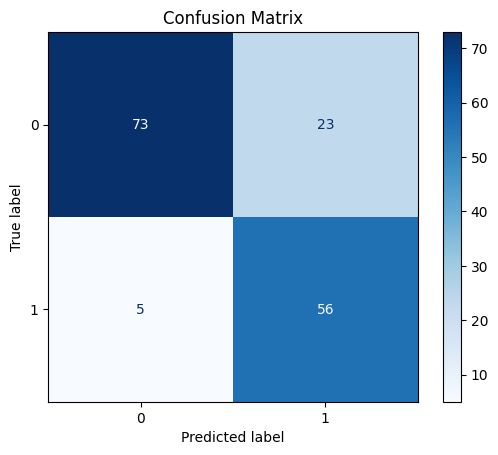

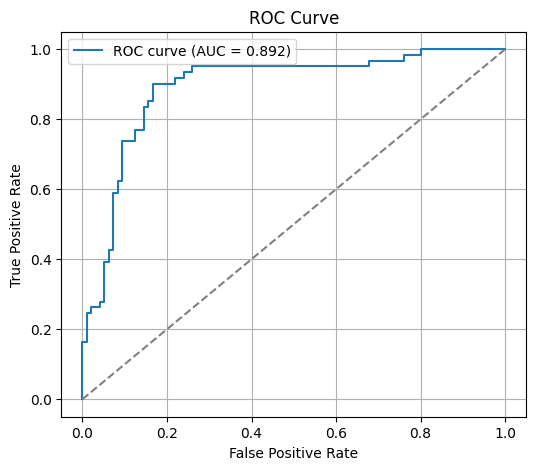

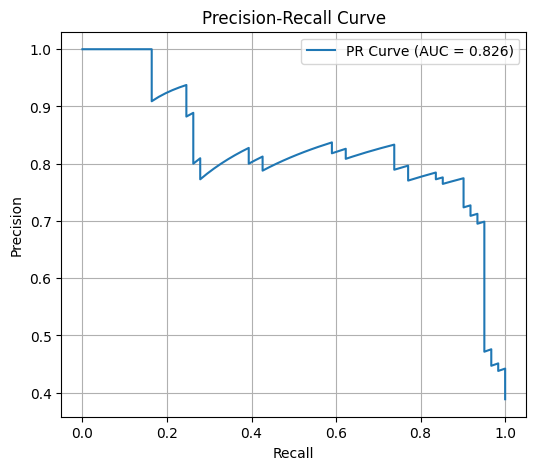

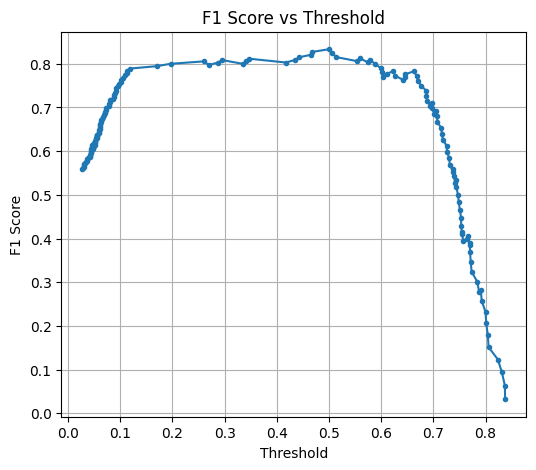

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score, auc,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve
)
from matplotlib import pyplot as plt
import numpy as np

# --- 1️⃣ SVM Grid Search Parameters ---
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto']
}

svm = SVC(
    random_state=42,
    probability=True,  # needed for predict_proba
    class_weight='balanced'  # handle imbalance
)

# --- 2️⃣ Grid Search ---
grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='roc_auc',
    verbose=2
)

grid.fit(X_train_scaled, y_train)

best_svm = grid.best_estimator_
print("✅ Best Parameters:", grid.best_params_)
print("✅ Best CV ROC AUC:", grid.best_score_)

# --- 3️⃣ Predictions ---
y_pred_train = best_svm.predict(X_train_scaled)
y_pred_test = best_svm.predict(X_test_scaled)
y_proba_test = best_svm.predict_proba(X_test_scaled)[:, 1]

# --- 4️⃣ Metrics ---
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
rmse = np.sqrt(mean_squared_error(y_test, y_proba_test))
mae = mean_absolute_error(y_test, y_proba_test)
r2 = r2_score(y_test, y_proba_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_test))
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"ROC AUC Score  : {roc_auc:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"R² Score       : {r2:.4f}")

# --- 5️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# --- 6️⃣ ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 7️⃣ Precision-Recall Curve ---
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_test)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 8️⃣ F1 vs Threshold ---
f1_scores = [f1_score(y_test, (y_proba_test >= thr).astype(int)) for thr in thresholds_pr]

plt.figure(figsize=(6,5))
plt.plot(thresholds_pr, f1_scores, marker='.')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, f1_score, auc,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve
)
from matplotlib import pyplot as plt
import numpy as np

# --- 1️⃣ LightGBM Classifier & Parameter Grid ---
lgb_clf = lgb.LGBMClassifier(
    random_state=42,
    class_weight='balanced',  # handle imbalance
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.5, 1]
}

# --- 2️⃣ Grid Search ---
grid = GridSearchCV(
    lgb_clf,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring='roc_auc',
    verbose=2
)
grid.fit(X_train_scaled, y_train)

best_lgb = grid.best_estimator_
print("✅ Best Parameters:", grid.best_params_)
print("✅ Best CV ROC AUC:", grid.best_score_)

# --- 3️⃣ Fit with Early Stopping ---
best_lgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    eval_metric='auc',
    early_stopping_rounds=20,
    verbose=10
)

# --- 4️⃣ Predictions ---
y_pred_train = best_lgb.predict(X_train_scaled)
y_pred_test = best_lgb.predict(X_test_scaled)
y_proba_test = best_lgb.predict_proba(X_test_scaled)[:, 1]

# --- 5️⃣ Metrics ---
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
rmse = np.sqrt(mean_squared_error(y_test, y_proba_test))
mae = mean_absolute_error(y_test, y_proba_test)
r2 = r2_score(y_test, y_proba_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_test))
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"ROC AUC Score  : {roc_auc:.4f}")
print(f"RMSE           : {rmse:.4f}")
print(f"MAE            : {mae:.4f}")
print(f"R² Score       : {r2:.4f}")

# --- 6️⃣ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# --- 7️⃣ ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 8️⃣ Precision-Recall Curve ---
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_test)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 9️⃣ F1 vs Threshold ---
f1_scores = [f1_score(y_test, (y_proba_test >= thr).astype(int)) for thr in thresholds_pr]

plt.figure(figsize=(6,5))
plt.plot(thresholds_pr, f1_scores, marker='.')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.grid(True)
plt.show()

# --- 🔟 Feature Importance ---
plt.figure(figsize=(10,6))
importance = best_lgb.feature_importances_
indices = np.argsort(importance)[::-1]
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), np.array(X_train_scaled.columns)[indices], rotation=90)
plt.title('Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()



NameError: name 'X_train_scaled' is not defined

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
fig = plt.figure(figsize=(8,5))
plt.barh(range(len(features)), importances[indices][::-1], align='center')
plt.yticks(range(len(features)), [features[i] for i in indices][::-1])
plt.xlabel('Importance')
plt.title('Importance des features (Random Forest)')
save_show(fig, '14_feature_importance.png')

NameError: name 'rf' is not defined